In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
from airquality.analysis.plotting import plot_effect, labels_map

svi_map = {
    'NO$_2$ (ppb)': 8,
    'SO$_2$ (ppb)': 7,
    'CO (ppm)': 6,
    'PM$_{2.5}$ ($\mu$g/m$^3$)': 5,
    'PM$_{10}$ ($\mu$g/m$^3$)': 4,
    'Temperature ($^{\circ}$C)': 3,
    'Relative Humidity (%)': 2,
    'Precipitation (mm)': 1,
    'SVI (%)': 0,
}

coi_map = {
    'NO$_2$ (ppb)': 8,
    'SO$_2$ (ppb)': 7,
    'CO (ppm)': 6,
    'PM$_{2.5}$ ($\mu$g/m$^3$)': 5,
    'PM$_{10}$ ($\mu$g/m$^3$)': 4,
    'Temperature ($^{\circ}$C)': 3,
    'Relative Humidity (%)': 2,
    'Precipitation (mm)': 1,
    'COI (%)': 0,
}


def joint_effect_plot(ax, info, socio_var, ticks_map):
    N = len(info.keys())
    dodge = 0.15
    offset = -dodge
    dodge_step = (2 * dodge) / (N - 1)
    for label, run_info in info.items():
        offset += dodge_step
        risk_df = pd.read_csv(os.path.join(os.environ['MODELS_DIR'], socio_var, run_info['path'], 'trial_effects.csv'))
        print(label)
        plot_effect(ax, risk_df, color=run_info['color'], label=label, 
                    labels_map=labels_map, ticks_map=ticks_map, offset=offset)
        print()

    ax.axvline(1, color='black', linestyle='--')
    ax.set_xlabel('Relative Risk')
    ax.legend(loc='lower right', framealpha=1);

GLM
 3.0, Temperature ($^{\circ}$C)     :    1.230 +/- 0.087
 2.0, Relative Humidity (%)         :    0.932 +/- 0.018
 6.0, CO (ppm)                      :    1.006 +/- 0.021
 0.0, COI (%)                       :    0.772 +/- 0.031
 8.0, NO$_2$ (ppb)                  :    1.273 +/- 0.036
 4.0, PM$_{10}$ ($\mu$g/m$^3$)      :    1.006 +/- 0.024
 5.0, PM$_{2.5}$ ($\mu$g/m$^3$)     :    0.961 +/- 0.016
 7.0, SO$_2$ (ppb)                  :    0.903 +/- 0.026
 1.0, Precipitation (mm)            :    0.990 +/- 0.012

Sparse
 3.1, Temperature ($^{\circ}$C)     :    1.047 +/- 0.182
 2.1, Relative Humidity (%)         :    0.932 +/- 0.031
 6.2, CO (ppm)                      :    1.017 +/- 0.028
 0.1, COI (%)                       :    0.699 +/- 0.043
 8.2, NO$_2$ (ppb)                  :    1.274 +/- 0.053
 4.2, PM$_{10}$ ($\mu$g/m$^3$)      :    0.989 +/- 0.059
 5.2, PM$_{2.5}$ ($\mu$g/m$^3$)     :    0.947 +/- 0.032
 7.2, SO$_2$ (ppb)                  :    0.996 +/- 0.061
 1.1, Precipitation

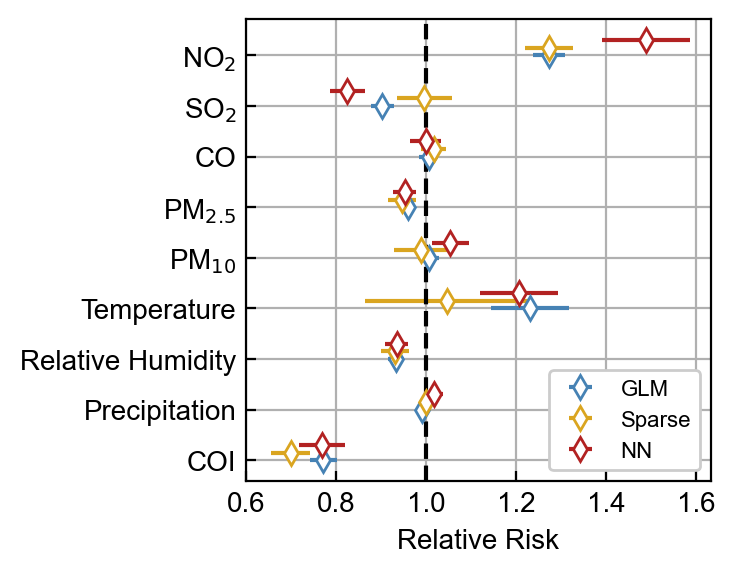

In [23]:
plt.rcParams['font.size'] = 10
plt.rcParams['legend.fontsize'] = 8
info = {
    'GLM': {
        'path': 'GLM/lag7/base/',
        'color': 'steelblue',
    },
    'Sparse': {
        'path': 'GLM/lag7/stlsq/',
        'color': 'goldenrod',
    },
    'NN': {
        'path': 'FCNN/lag7',
        'color': 'firebrick',
    }
}

socio_var, ticks_map = 'coi', coi_map
fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=200)
joint_effect_plot(ax, info, socio_var, ticks_map)

short_labels = []
for label in ax.get_yticklabels():
    label.set_text(label.get_text().split('(')[0][:-1])
    short_labels.append(label)
ax.set_yticklabels(short_labels)

ax.set_xticks([0.6, 0.8, 1, 1.2, 1.4, 1.6])

plt.savefig(os.path.join(os.environ['MODELS_DIR'], socio_var, 'risk_ratio_comparison.pdf'), bbox_inches='tight')

In [ ]:
# Look at model IQRs, make sure they're the same for each (Looks Good)
df = []
for label, run_info in info.items():
    for root, folder, files in os.walk(os.path.join(os.environ['MODELS_DIR'], 'coi', run_info['path'])):
        if 'interquartile_range.csv' in files:
            df.append(pd.read_csv(f'{root}/interquartile_range.csv').assign(model=label))

df = pd.concat(df).rename({'Unnamed: 0': 'parameter', '0': 'IQR'}, axis=1) \
    .groupby(['model', 'parameter'])['IQR'] .agg('mean')
pd.set_option('display.max_rows', 100)
df.reset_index().pivot(
    index='parameter', columns='model',
)

IQR                          
model                              GLM           NN       Sparse
parameter                                                       
AQI                          10.000000    10.000000    10.000000
AverageDryBulbTemperature    13.879729    13.879729    13.879729
AverageRelativeHumidity      10.337344    10.337344    10.337344
AverageStationPressure        5.400916     5.400916     5.400916
AverageWindSpeed              1.259244     1.259244     1.259244
CO                            0.100177     0.100177     0.100177
COI_education_perc           45.000000    45.000000    45.000000
COI_health_env_perc          26.000000    26.000000    26.000000
COI_overall_perc             38.000000    38.000000    38.000000
COI_socioeco_perc            36.000000    36.000000    36.000000
EPL_AGE17                     0.228800     0.228800     0.228800
EPL_AGE65                     0.138100     0.138100     0.138100
EPL_CROWD                     0.162300     0.162300     0.162300
EPL_DISABL                    0.265100     0.265100     0.265100
EPL_GROUPQ                    0.186900     0.186900     0.186900
EPL_HBURD                     0.152900     0.152900     0.152900
EPL_LIMENG                    0.223100     0.223100     0.223100
EPL_MINRTY                    0.199400     0.199400     0.199400
EPL_MOBILE                    0.119000     0.119000     0.119000
EPL_MUNIT                     0.128100     0.128100     0.128100
EPL_NOHSDP                    0.255700     0.255700     0.255700
EPL_NOVEH                     0.245700     0.245700     0.245700
EPL_POV150                    0.317900     0.317900     0.317900
EPL_SNGPNT                    0.184200     0.184200     0.184200
EPL_UNEMP                     0.240500     0.240500     0.240500
EPL_UNINSUR                   0.258300     0.258300     0.258300
EP_AFAM                      26.100000    26.100000    26.100000
EP_AGE17                      3.700000     3.700000     3.700000
EP_AGE65                      3.200000     3.200000     3.200000
EP_AIAN                       0.200000     0.200000     0.200000
EP_ASIAN                      3.300000     3.300000     3.300000
EP_CROWD                      1.100000     1.100000     1.100000
EP_DISABL                     4.200000     4.200000     4.200000
EP_GROUPQ                     1.400000     1.400000     1.400000
EP_HBURD                     10.600000    10.600000    10.600000
EP_HISP                       3.500000     3.500000     3.500000
EP_LIMENG                     1.300000     1.300000     1.300000
EP_MINRTY                    22.800000    22.800000    22.800000
EP_MOBILE                     1.900000     1.900000     1.900000
EP_MUNIT                      8.400000     8.400000     8.400000
EP_NHPI                       0.100000     0.100000     0.100000
EP_NOHSDP                     4.700000     4.700000     4.700000
EP_NOINT                      7.400000     7.400000     7.400000
EP_NOVEH                      4.400000     4.400000     4.400000
EP_OTHERRACE                  0.400000     0.400000     0.400000
EP_POV150                    10.700000    10.700000    10.700000
EP_SNGPNT                     4.400000     4.400000     4.400000
EP_TWOMORE                    1.400000     1.400000     1.400000
EP_UNEMP                      2.800000     2.800000     2.800000
EP_UNINSUR                    3.200000     3.200000     3.200000
HeatIndex                    15.592354    15.592354    15.592354
NO2                           3.319529     3.319529     3.319529
O3                            0.009078     0.009078     0.009078
PM10                          5.130524     5.130524     5.130524
PM25                          2.334297     2.334297     2.334297
SO2                           0.408340     0.408340     0.408340
SVI_household_perc            0.195900     0.195900     0.195900
SVI_housing_perc              0.155300     0.155300     0.155300
SVI_overall_perc              0.166500     0.166500     0.166500
SVI_r

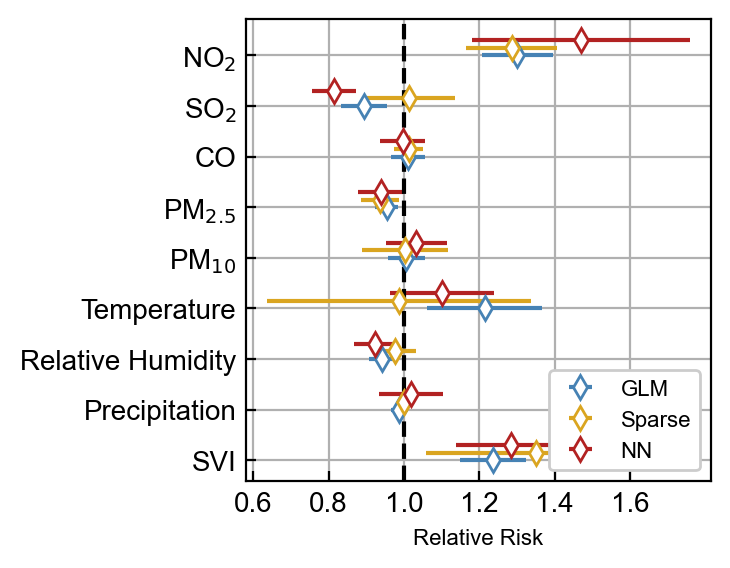

In [50]:
socio_var, ticks_map = 'svi', svi_map
fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=200)
joint_effect_plot(ax, info, socio_var, ticks_map)

short_labels = []
for label in ax.get_yticklabels():
    label.set_text(label.get_text().split('(')[0][:-1])
    short_labels.append(label)
ax.set_yticklabels(short_labels)

ax.set_xticks([0.6, 0.8, 1, 1.2, 1.4, 1.6])

plt.savefig(os.path.join(os.environ['MODELS_DIR'], socio_var, 'risk_ratio_comparison.pdf'), bbox_inches='tight')

# Sensitivity of each model to SVI $\leftrightarrow$ COI

 2.9, Relative Humidity (%)         :    1.230 +/- 0.087
 1.9, Precipitation (mm)            :    0.932 +/- 0.018
 5.8, PM$_{2.5}$ ($\mu$g/m$^3$)     :    1.006 +/- 0.021
-0.1, COI (%)                       :    0.772 +/- 0.031
 7.8, SO$_2$ (ppb)                  :    1.273 +/- 0.036
 3.9, Temperature ($^{\circ}$C)     :    1.006 +/- 0.024
 4.8, PM$_{10}$ ($\mu$g/m$^3$)      :    0.961 +/- 0.016
 6.8, CO (ppm)                      :    0.903 +/- 0.026
 0.8, COI (%)                       :    0.990 +/- 0.012
 3.1, Temperature ($^{\circ}$C)     :    1.214 +/- 0.078
 2.1, Relative Humidity (%)         :    0.942 +/- 0.018
 6.2, CO (ppm)                      :    1.010 +/- 0.023
 8.2, NO$_2$ (ppb)                  :    1.300 +/- 0.048
 4.2, PM$_{10}$ ($\mu$g/m$^3$)      :    1.006 +/- 0.025
 5.2, PM$_{2.5}$ ($\mu$g/m$^3$)     :    0.954 +/- 0.016
 7.2, SO$_2$ (ppb)                  :    0.894 +/- 0.031
-0.8, COI (%)                       :    1.238 +/- 0.045
 1.1, Precipitation (mm)       

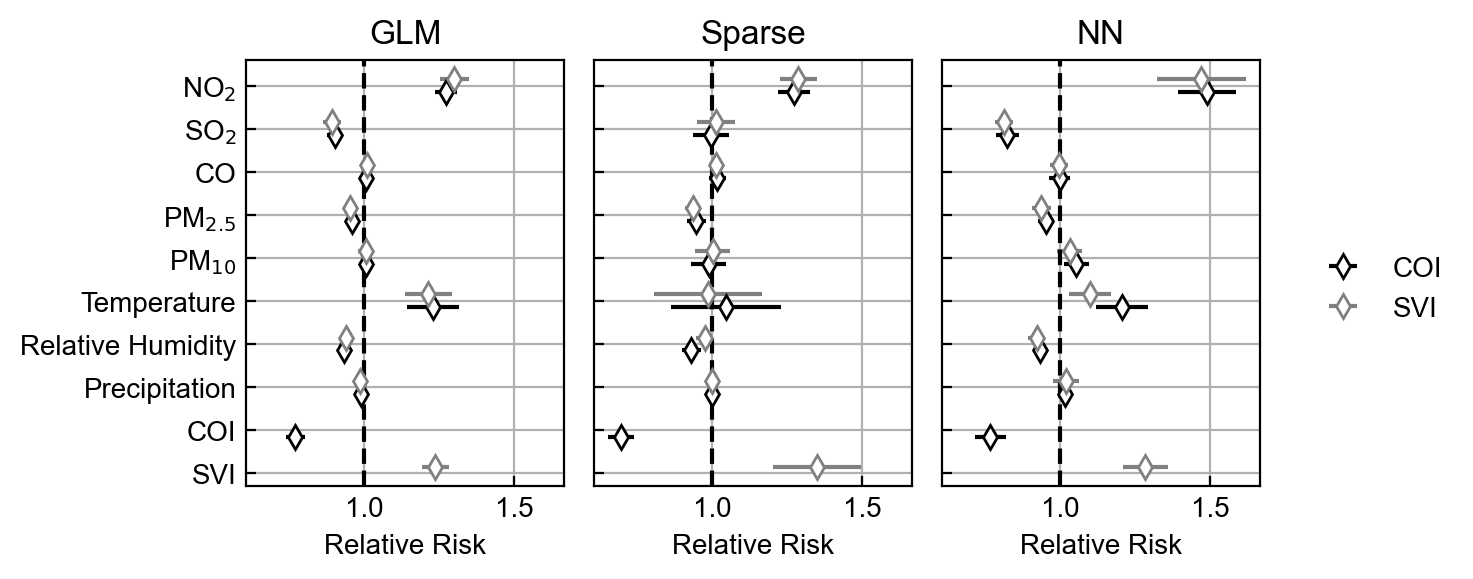

In [4]:
ticks_map = {
    'NO$_2$ (ppb)': 8,
    'SO$_2$ (ppb)': 7,
    'CO (ppm)': 6,
    'PM$_{2.5}$ ($\mu$g/m$^3$)': 5,
    'PM$_{10}$ ($\mu$g/m$^3$)': 4,
    'Temperature ($^{\circ}$C)': 3,
    'Relative Humidity (%)': 2,
    'Precipitation (mm)': 1,
    'COI (%)': 0,
    'SVI (%)': -1,
}

info = {
    'GLM': {
        'path': 'GLM/lag7/base/',
        'color': 'steelblue',
    },
    'Sparse': {
        'path': 'GLM/lag7/stlsq/',
        'color': 'goldenrod',
    },
    'NN': {
        'path': 'FCNN/lag7',
        'color': 'firebrick',
    }
}

fig, axes = plt.subplots(1, 3, dpi=200, sharex=True, sharey=True, figsize=(6.5, 3))
for ax, label in zip(axes.flatten(), ['GLM', 'Sparse', 'NN']):
    run_info = info[label]
    offset = -0.15
    dodge_step = 0.3
    for socio_var, color in zip(['coi', 'svi'], ['black', 'grey']):
        risk_df = pd.read_csv(os.path.join(os.environ['MODELS_DIR'], socio_var, run_info['path'], 'trial_effects.csv'))
        plot_effect(ax, risk_df, color=color, label=socio_var.upper(), 
                    labels_map=labels_map, ticks_map=ticks_map, offset=offset)
        offset += dodge_step

    ax.axvline(1, color='black', linestyle='--')
    ax.set_xlabel('Relative Risk')
    ax.set_title(label)
    
short_labels = []
for label in axes[0].get_yticklabels():
    label.set_text(label.get_text().split('(')[0][:-1])
    short_labels.append(label)
axes[0].set_yticklabels(short_labels)

fig.legend(*ax.get_legend_handles_labels(), loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)
plt.tight_layout()

plt.savefig(os.path.join(os.environ['MODELS_DIR'], 'social_sensitivity.pdf'), bbox_inches='tight')

# With Ozone

Without O$_3$
 3.1, Temperature ($^{\circ}$C)     :    1.230 +/- 0.087
 2.1, Relative Humidity (%)         :    0.932 +/- 0.018
 6.2, CO (ppm)                      :    1.006 +/- 0.021
 0.1, COI (%)                       :    0.772 +/- 0.031
 8.2, NO$_2$ (ppb)                  :    1.273 +/- 0.036
 4.2, PM$_{10}$ ($\mu$g/m$^3$)      :    1.006 +/- 0.024
 5.2, PM$_{2.5}$ ($\mu$g/m$^3$)     :    0.961 +/- 0.016
 7.2, SO$_2$ (ppb)                  :    0.903 +/- 0.026
 1.1, Precipitation (mm)            :    0.990 +/- 0.012

With O$_3$
 3.5, Temperature ($^{\circ}$C)     :    0.972 +/- 0.084
 2.5, Relative Humidity (%)         :    0.958 +/- 0.024
 6.5, CO (ppm)                      :    0.987 +/- 0.023
 0.4, COI (%)                       :    0.758 +/- 0.027
 8.4, NO$_2$ (ppb)                  :    1.353 +/- 0.054
 9.4, O$_3$ (ppm)                   :    1.071 +/- 0.033
 4.5, PM$_{10}$ ($\mu$g/m$^3$)      :    1.064 +/- 0.033
 5.5, PM$_{2.5}$ ($\mu$g/m$^3$)     :    0.960 +/- 0.019
 7.5,

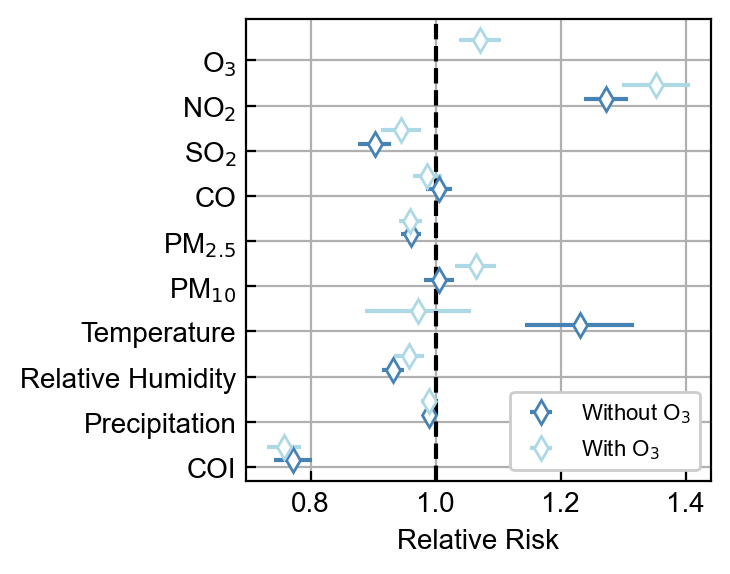

In [5]:
ticks_map = {
    'O$_3$ (ppm)': 9,
    'NO$_2$ (ppb)': 8,
    'SO$_2$ (ppb)': 7,
    'CO (ppm)': 6,
    'PM$_{2.5}$ ($\mu$g/m$^3$)': 5,
    'PM$_{10}$ ($\mu$g/m$^3$)': 4,
    'Temperature ($^{\circ}$C)': 3,
    'Relative Humidity (%)': 2,
    'Precipitation (mm)': 1,
    'COI (%)': 0,
}

plt.rcParams['font.size'] = 10
plt.rcParams['legend.fontsize'] = 8
info = {
    'Without O$_3$': {
        'path': 'GLM/lag7/base/',
        'color': 'steelblue',
    },
    'With O$_3$': {
        'path': 'GLM/ozone/base/',
        'color': 'lightblue',
    },
}

socio_var = 'coi'
fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=200)
joint_effect_plot(ax, info, socio_var, ticks_map)

short_labels = []
for label in ax.get_yticklabels():
    label.set_text(label.get_text().split('(')[0][:-1])
    short_labels.append(label)
ax.set_yticklabels(short_labels)

ax.set_xticks([0.8, 1, 1.2, 1.4])
plt.savefig(os.path.join(os.environ['MODELS_DIR'], socio_var, 'ozone_comparison.pdf'), bbox_inches='tight')